In [6]:
import numpy as np

In [1]:
import anndata as ad

In [2]:
tahoe_a549 = ad.read_h5ad("../../data/degs/tahoe_a549_deg_adata.h5ad")
sciplex_a549 = ad.read_h5ad("../../data/degs/sciplex3_a549_deg_adata.h5ad")

In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 1) Make your var_names = gene_symbol and drop duplicates
# -----------------------------------------------------------------
# Assign gene_symbol to var_names (the AnnData “column names” axis)
sciplex_a549.var_names = sciplex_a549.var['gene_symbol'].values
tahoe_a549.var_names  = tahoe_a549.var['gene_symbol'].values

# Drop any duplicate gene_symbols (keeps the first)
keep_sciplex = ~sciplex_a549.var_names.duplicated(keep='first')
keep_tahoe  = ~tahoe_a549.var_names.duplicated(keep='first')

sciplex_a549 = sciplex_a549[:, keep_sciplex].copy()
tahoe_a549  = tahoe_a549[:, keep_tahoe].copy()

# 2) Find the intersection of gene names
# -----------------------------------------------------------------
common_genes = sciplex_a549.var_names.intersection(tahoe_a549.var_names)

# 3) Subset both AnnData’s to that shared set (and .copy() so nothing weird leaks)
# -----------------------------------------------------------------
sciplex_sub = sciplex_a549[:, common_genes].copy()
tahoe_sub  = tahoe_a549[:,  common_genes].copy()

# 4) Pull out your log-FC and adj-pval layers
# -----------------------------------------------------------------
lfc_a = sciplex_sub.layers['logfc']
lfc_b = tahoe_sub.layers['logfc']
padj_a = sciplex_sub.layers['adj_p_value']
padj_b = tahoe_sub.layers['adj_p_value']

# 5) Build signed –log10-pval signatures (more standard than sign * log10)
# -----------------------------------------------------------------
signed_a = np.sign(lfc_a) * -np.log10(padj_a)
signed_b = np.sign(lfc_b) * -np.log10(padj_b)

# 6) Cosine-similarity between every A vs. every B contrast
# -----------------------------------------------------------------
cos_sim = cosine_similarity(signed_a, signed_b)

# 7) Put into a pandas DataFrame
# -----------------------------------------------------------------
sim_df = pd.DataFrame(
    cos_sim,
    index = sciplex_sub.obs_names,
    columns= tahoe_sub.obs_names
)

sim_df

/Users/arturszalata/miniconda3/envs/op3/lib/python3.12/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['TNMD', 'DPM1', 'SCYL3', 'FGR', 'CFH']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


condition,APTO_253_0_05_uM__A549,APTO_253_0_5_uM__A549,APTO_253_5_0_uM__A549,AT7519_0_05_uM__A549,AT7519_0_5_uM__A549,AT7519_5_0_uM__A549,AZD1390_0_05_uM__A549,AZD1390_0_5_uM__A549,AZD1390_5_0_uM__A549,AZD2858_0_05_uM__A549,...,palbociclib_5_0_uM__A549,venetoclax_0_05_uM__A549,venetoclax_0_5_uM__A549,venetoclax_5_0_uM__A549,vincristine_0_05_uM__A549,vincristine_0_5_uM__A549,vincristine_5_0_uM__A549,γ_Oryzanol_0_05_uM__A549,γ_Oryzanol_0_5_uM__A549,γ_Oryzanol_5_0_uM__A549
condition,,,,,,,,,,,,,,,,,,,,,
AV_939_10000_0_A549,-0.064974,-0.005641,-0.005647,-0.060110,-0.003647,-0.002600,-0.044805,0.015860,0.014286,-0.035265,...,-0.005015,-0.039954,0.002243,0.014718,-0.014135,0.005934,0.003758,0.007314,0.006162,-0.004490
AV_939_1000_0_A549,-0.027996,0.005933,-0.009326,-0.018269,-0.000464,-0.002036,-0.025480,0.001728,-0.004867,-0.011102,...,-0.012872,-0.012623,0.010191,0.010085,0.004725,0.004196,0.003403,0.001871,0.002866,0.001193
AV_939_100_0_A549,-0.006269,-0.001558,-0.021272,-0.013166,-0.005237,0.002785,-0.007598,-0.003966,-0.000956,-0.033225,...,-0.010812,-0.015954,0.002021,-0.010888,-0.004953,-0.005033,-0.014310,0.007673,0.009035,-0.001220
AV_939_10_0_A549,-0.019246,0.008869,-0.005532,-0.024852,-0.012171,-0.006816,-0.022882,-0.002180,-0.000414,-0.016539,...,-0.000499,0.002781,0.023134,-0.015919,-0.010353,-0.011157,-0.012582,0.001575,0.003534,0.001053
JQ1_10000_0_A549,-0.017176,0.001179,-0.003370,-0.002992,0.004561,0.004169,0.002591,0.005727,0.010840,-0.010168,...,0.023959,-0.005491,-0.018449,0.006792,-0.011523,0.001429,-0.000033,0.000562,0.000346,0.001457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
factor_valid_drug_names_ZM_447439_10_0_A549,-0.031342,-0.005497,-0.009478,-0.031290,-0.000461,0.002070,-0.030295,-0.001896,0.003339,-0.017876,...,-0.014784,-0.028695,-0.007649,-0.000419,-0.010181,-0.001797,0.005683,0.001461,0.000042,-0.000475
factor_valid_drug_names_Zileuton_10000_0_A549,0.007202,0.005075,0.007126,-0.010072,-0.002628,-0.005871,-0.004884,0.004324,0.007726,-0.007682,...,-0.004597,-0.016682,0.012672,-0.014582,-0.004599,-0.005898,-0.012884,0.017273,0.010493,-0.001891
factor_valid_drug_names_Zileuton_1000_0_A549,-0.001421,0.000430,0.000679,-0.000952,-0.017736,-0.020190,-0.028379,-0.005594,-0.003385,-0.004216,...,0.002337,0.000664,-0.002357,-0.003404,-0.010087,-0.009533,-0.015651,0.000257,-0.000079,0.000039


In [61]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 1) Make your var_names = gene_symbol and drop duplicates
# -----------------------------------------------------------------
# Assign gene_symbol to var_names (the AnnData "column names" axis)
sciplex_a549.var_names = sciplex_a549.var['gene_symbol'].values
tahoe_a549.var_names  = tahoe_a549.var['gene_symbol'].values

# Drop any duplicate gene_symbols (keeps the first)
keep_sciplex = ~sciplex_a549.var_names.duplicated(keep='first')
keep_tahoe  = ~tahoe_a549.var_names.duplicated(keep='first')

sciplex_a549 = sciplex_a549[:, keep_sciplex].copy()
tahoe_a549  = tahoe_a549[:, keep_tahoe].copy()

# 2) Find the intersection of gene names
# -----------------------------------------------------------------
common_genes = sciplex_a549.var_names.intersection(tahoe_a549.var_names)

# 3) Subset both AnnData's to that shared set (and .copy() so nothing weird leaks)
# -----------------------------------------------------------------
sciplex_sub = sciplex_a549[:, common_genes].copy()
tahoe_sub  = tahoe_a549[:,  common_genes].copy()

# 4) Pull out adj_p_value layers
# -----------------------------------------------------------------
padj_a = sciplex_sub.layers['adj_p_value']
padj_b = tahoe_sub.layers['adj_p_value']

# 5) Calculate cosine similarity between adjusted p-values
# -----------------------------------------------------------------
cos_sim = cosine_similarity(padj_a, padj_b)

# 6) Put into a pandas DataFrame
# -----------------------------------------------------------------
sim_df = pd.DataFrame(
    cos_sim,
    index = sciplex_sub.obs_names,
    columns= tahoe_sub.obs_names
)

sim_df

/Users/arturszalata/miniconda3/envs/op3/lib/python3.12/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['TNMD', 'DPM1', 'SCYL3', 'FGR', 'CFH']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


condition,APTO_253_0_05_uM__A549,APTO_253_0_5_uM__A549,APTO_253_5_0_uM__A549,AT7519_0_05_uM__A549,AT7519_0_5_uM__A549,AT7519_5_0_uM__A549,AZD1390_0_05_uM__A549,AZD1390_0_5_uM__A549,AZD1390_5_0_uM__A549,AZD2858_0_05_uM__A549,...,palbociclib_5_0_uM__A549,venetoclax_0_05_uM__A549,venetoclax_0_5_uM__A549,venetoclax_5_0_uM__A549,vincristine_0_05_uM__A549,vincristine_0_5_uM__A549,vincristine_5_0_uM__A549,γ_Oryzanol_0_05_uM__A549,γ_Oryzanol_0_5_uM__A549,γ_Oryzanol_5_0_uM__A549
condition,,,,,,,,,,,,,,,,,,,,,
AV_939_10000_0_A549,0.939146,0.946170,0.947180,0.943313,0.947730,0.943969,0.925780,0.941187,0.937727,0.941059,...,0.913199,0.916871,0.923748,0.810806,0.933820,0.843886,0.885543,0.948189,0.948085,0.948045
AV_939_1000_0_A549,0.988197,0.995031,0.996219,0.992061,0.996821,0.992978,0.973544,0.989934,0.986278,0.990751,...,0.960868,0.964842,0.971649,0.852847,0.981882,0.890496,0.932849,0.997249,0.997174,0.997178
AV_939_100_0_A549,0.988355,0.995027,0.996302,0.992104,0.996867,0.993059,0.973621,0.989922,0.986325,0.990872,...,0.960975,0.964834,0.971959,0.853069,0.981767,0.890231,0.932671,0.997269,0.997209,0.997194
AV_939_10_0_A549,0.986717,0.993529,0.994715,0.990716,0.995315,0.991451,0.972258,0.988371,0.984677,0.989309,...,0.959488,0.963303,0.970484,0.851698,0.980295,0.889245,0.931156,0.995696,0.995633,0.995640
JQ1_10000_0_A549,0.804087,0.809672,0.811404,0.807426,0.811118,0.808108,0.792302,0.805551,0.802039,0.804992,...,0.783271,0.784469,0.790831,0.698471,0.798345,0.727587,0.760814,0.811498,0.811347,0.811433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
factor_valid_drug_names_ZM_447439_10_0_A549,0.985524,0.991992,0.993249,0.989168,0.993741,0.989864,0.971099,0.986841,0.983127,0.987685,...,0.957975,0.962191,0.968958,0.851057,0.978682,0.888557,0.930226,0.994201,0.994127,0.994127
factor_valid_drug_names_Zileuton_10000_0_A549,0.986676,0.993297,0.994529,0.990379,0.995034,0.991245,0.972285,0.988458,0.984529,0.989342,...,0.958833,0.963251,0.970198,0.851226,0.980113,0.889092,0.931211,0.995524,0.995460,0.995457
factor_valid_drug_names_Zileuton_1000_0_A549,0.990521,0.997290,0.998485,0.994276,0.999088,0.995240,0.975960,0.992076,0.988461,0.993054,...,0.963059,0.967220,0.974017,0.855051,0.983986,0.892639,0.935111,0.999479,0.999416,0.999417


In [ ]:
import pandas as pd
import pubchempy as pcp
from tqdm import tqdm

# (1) Extract unique drug names
tahoe_drugs = pd.Series(tahoe_sub.obs.drug_name.unique(), name='drug_name')
sciplex_drugs = pd.Series(sciplex_sub.obs.drug_name.unique(), name='drug_name')

# Helper to fetch a PubChem CID for a given name (or None if not found)
def get_cid(name):
    try:
        # returns a list of Compound objects; grab the first CID if available
        comps = pcp.get_compounds(name, 'name')
        return comps[0].cid if comps else None
    except Exception:
        return None

# (2) Build mapping DataFrames by querying PubChem
tqdm.pandas(desc="Fetching Tahoe CIDs")
tahoe_map = tahoe_drugs.to_frame().drop_duplicates().assign(
    pubchem_id=lambda df: df['drug_name'].progress_apply(get_cid)
)

tqdm.pandas(desc="Fetching SciPlex CIDs")
sciplex_map = sciplex_drugs.to_frame().drop_duplicates().assign(
    pubchem_id=lambda df: df['drug_name'].progress_apply(get_cid)
)

# (3) Find overlaps
tahoe_cids   = set(tahoe_map['pubchem_id'].dropna())
sciplex_cids = set(sciplex_map['pubchem_id'].dropna())
common_cids  = tahoe_cids & sciplex_cids

# (4) List the drug names that correspond to those shared CIDs
common_tahoe = tahoe_map[tahoe_map['pubchem_id'].isin(common_cids)]['drug_name']
common_sciplex = sciplex_map[sciplex_map['pubchem_id'].isin(common_cids)]['drug_name']

print(f"Number of drugs in Tahoe dataset:      {len(tahoe_drugs)}")
print(f"Number of drugs in SciPlex dataset:    {len(sciplex_drugs)}")
print(f"Number of drugs with matching CIDs:    {len(common_cids)}")
print("\nCommon drugs in Tahoe:")
print(common_tahoe.tolist())
print("\nCommon drugs in SciPlex:")
print(common_sciplex.tolist())

Fetching SciPlex CIDs: 100%|██████████| 188/188 [01:45<00:00,  1.78it/s]

Number of drugs in Tahoe dataset:      379
Number of drugs in SciPlex dataset:    188
Number of drugs with matching CIDs:    22

Common drugs in Tahoe:
['Altretamine', 'Belinostat', 'Busulfan', 'Celecoxib', 'Decitabine', 'Filgotinib', 'Fulvestrant', 'Lapatinib ditosylate', 'Panobinostat', 'Raltitrexed', 'Regorafenib', 'Resveratrol', 'Roxadustat', 'Rucaparib (phosphate)', 'TAK-901', 'Tofacitinib (citrate)', 'Trametinib', 'Vandetanib', '5-Azacytidine', '5-Fluorouracil', 'Zileuton', 'crizotinib']

Common drugs in SciPlex:
['Altretamine', 'Azacitidine ', 'Belinostat (PXD101)', 'Busulfan ', 'Celecoxib', 'Crizotinib (PF-02341066)', 'Decitabine', 'Filgotinib (GLPG0634)', 'Fluorouracil (5-Fluoracil, 5-FU)', 'Fulvestrant', 'Lapatinib (GW-572016) Ditosylate', 'Panobinostat (LBH589)', 'Raltitrexed', 'Regorafenib (BAY 73-4506)', 'Resveratrol', 'Roxadustat (FG-4592)', 'Rucaparib (AG-014699,PF-01367338) phosphate', 'TAK-901', 'Tofacitinib (CP-690550) Citrate', 'Trametinib (GSK1120212)', 'Vandetanib 

In [62]:
tahoe_sub.obs['pubchem_cid'] = tahoe_sub.obs['drug_name'].map(tahoe_map.set_index('drug_name')['pubchem_id'])
sciplex_sub.obs['pubchem_cid'] = sciplex_sub.obs['drug_name'].map(sciplex_map.set_index('drug_name')['pubchem_id'])

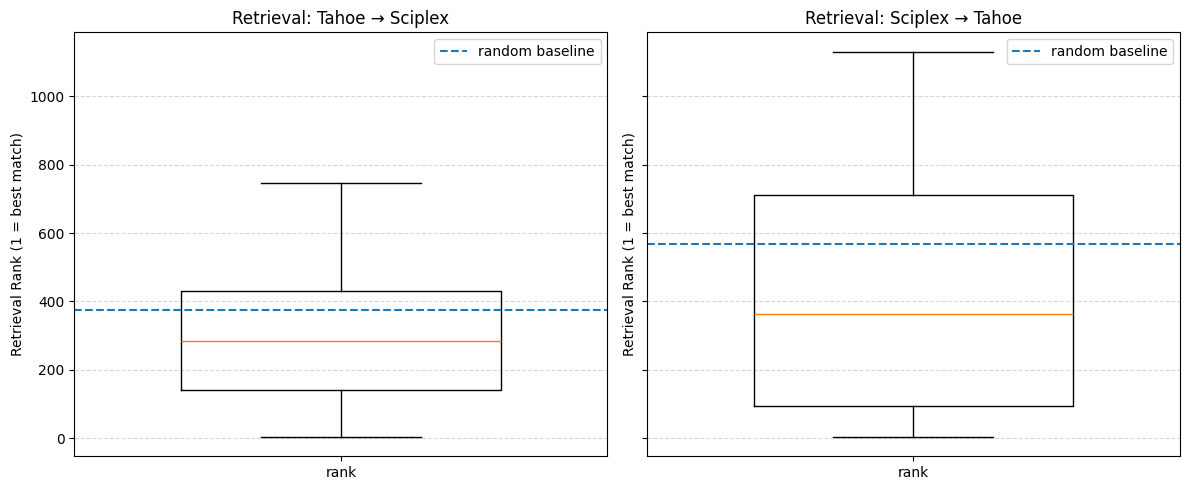

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_matches(label, obs_a, obs_b):
    meta = obs_a.loc[label]
    cid, dose = meta['pubchem_cid'], meta['dosage_uM']
    sub = obs_b[obs_b['pubchem_cid'] == cid]
    if sub.empty:
        return []
    lower = sub[sub['dosage_uM'] <= dose]
    higher = sub[sub['dosage_uM'] >= dose]
    matches = []
    if not lower.empty:
        closest_low = lower['dosage_uM'].max()
        matches += lower[lower['dosage_uM'] == closest_low].index.tolist()
    if not higher.empty:
        closest_high = higher['dosage_uM'].min()
        for idx in higher[higher['dosage_uM'] == closest_high].index:
            if idx not in matches:
                matches.append(idx)
    return matches

def compute_retrieval_ranks(sim, obs_q, obs_db):
    ranks = {}
    for q in sim.index:
        true_bs = find_matches(q, obs_q, obs_db)
        if not true_bs:
            ranks[q] = np.nan
            continue
        sorted_cols = sim.loc[q].sort_values(ascending=False).index
        pos = [np.where(sorted_cols == b)[0][0] + 1 for b in true_bs if b in sorted_cols]
        ranks[q] = min(pos) if pos else np.nan
    return pd.Series(ranks, name='rank')

# 1) Tahoe→Sciplex
ranks_t2s = compute_retrieval_ranks(sim_df.T, tahoe_sub.obs, sciplex_sub.obs)
# 2) Sciplex→Tahoe
ranks_s2t = compute_retrieval_ranks(sim_df, sciplex_sub.obs, tahoe_sub.obs)

# baseline: random expected rank = (N+1)/2
n_sciplex = sim_df.shape[0]
n_tahoe   = sim_df.shape[1]
rand_t2s = (n_sciplex + 1) / 2
rand_s2t = (n_tahoe   + 1) / 2

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].boxplot(ranks_t2s.dropna(), widths=0.6)
axes[0].axhline(rand_t2s, linestyle='--', label='random baseline')
axes[0].set_title("Retrieval: Tahoe → Sciplex")
axes[0].set_xticks([1])
axes[0].set_xticklabels(["rank"])
axes[0].legend()

axes[1].boxplot(ranks_s2t.dropna(), widths=0.6)
axes[1].axhline(rand_s2t, linestyle='--', label='random baseline')
axes[1].set_title("Retrieval: Sciplex → Tahoe")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["rank"])
axes[1].legend()

for ax in axes:
    ax.set_ylabel("Retrieval Rank (1 = best match)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

/Users/arturszalata/miniconda3/envs/op3/lib/python3.12/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['TNMD', 'DPM1', 'SCYL3', 'FGR', 'CFH']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


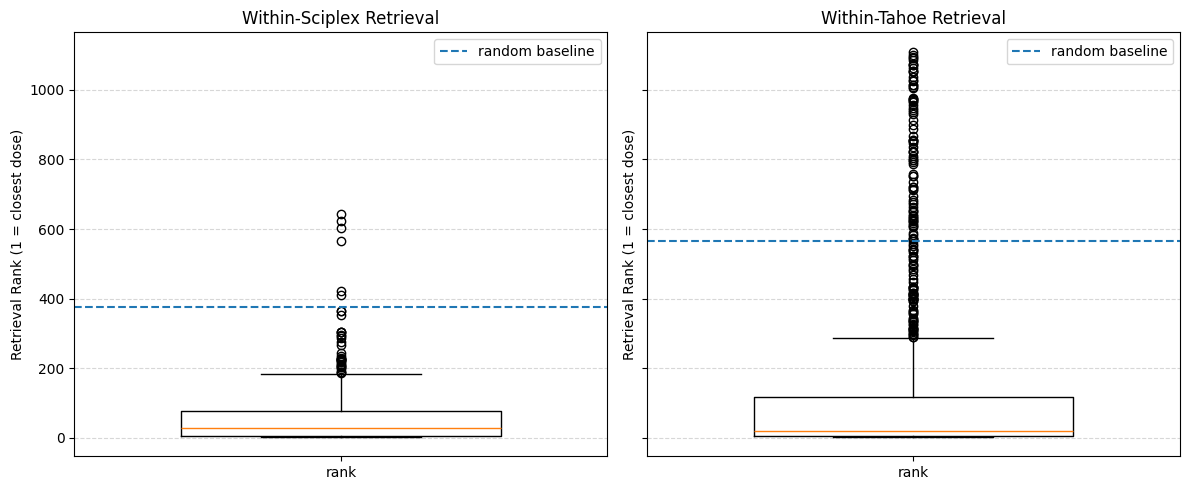

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def prepare_signed_padj(adata):
    # set gene_symbol as var_names and drop duplicates
    adata.var_names = adata.var['gene_symbol'].values
    keep = ~adata.var_names.duplicated(keep='first')
    adata = adata[:, keep].copy()
    # build signed –log10(p) signature
    lfc   = adata.layers['logfc']
    padj  = adata.layers['adj_p_value']
    signed = np.sign(lfc) * -np.log10(padj)
    return signed, adata.obs

def compute_sim_df(signed, obs):
    sims = cosine_similarity(signed, signed)
    return pd.DataFrame(sims, index=obs.index, columns=obs.index)

def find_matches(label, obs):
    meta = obs.loc[label]
    cid, dose = meta['pubchem_cid'], meta['dosage_uM']
    sub = obs[obs['pubchem_cid'] == cid]
    if sub.empty:
        return []
    lower  = sub[sub['dosage_uM'] < dose]
    higher = sub[sub['dosage_uM'] > dose]
    matches = []
    if not lower.empty:
        d_low = lower['dosage_uM'].max()
        matches += lower[lower['dosage_uM'] == d_low].index.tolist()
    if not higher.empty:
        d_high = higher['dosage_uM'].min()
        for idx in higher[higher['dosage_uM'] == d_high].index:
            if idx not in matches:
                matches.append(idx)
    # exclude self-match if dose exactly equals
    return [m for m in matches if m != label]

def compute_retrieval_ranks(sim_df, obs):
    ranks = {}
    for q in sim_df.index:
        true_bs = find_matches(q, obs)
        if not true_bs:
            ranks[q] = np.nan
            continue
        sorted_idx = sim_df.loc[q].sort_values(ascending=False).index
        positions = [np.where(sorted_idx == b)[0][0] + 1
                     for b in true_bs if b in sorted_idx]
        ranks[q] = min(positions) if positions else np.nan
    return pd.Series(ranks, name='rank')

# prepare both datasets
signed_sci, obs_sci   = prepare_signed_padj(sciplex_sub)
signed_tah, obs_tah   = prepare_signed_padj(tahoe_sub)

# compute within‐dataset similarity matrices
sim_sci = compute_sim_df(signed_sci, obs_sci)
sim_tah = compute_sim_df(signed_tah, obs_tah)

# compute retrieval ranks
ranks_sci = compute_retrieval_ranks(sim_sci, obs_sci)
ranks_tah = compute_retrieval_ranks(sim_tah, obs_tah)

# random‐baseline = (N+1)/2
rand_sci = (sim_sci.shape[0] + 1) / 2
rand_tah = (sim_tah.shape[0] + 1) / 2

# plot side‐by‐side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].boxplot(ranks_sci.dropna(), widths=0.6)
axes[0].axhline(rand_sci, linestyle='--', label='random baseline')
axes[0].set_title("Within-Sciplex Retrieval")
axes[0].set_xticks([1])
axes[0].set_xticklabels(["rank"])
axes[0].legend()

axes[1].boxplot(ranks_tah.dropna(), widths=0.6)
axes[1].axhline(rand_tah, linestyle='--', label='random baseline')
axes[1].set_title("Within-Tahoe Retrieval")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["rank"])
axes[1].legend()

for ax in axes:
    ax.set_ylabel("Retrieval Rank (1 = closest dose)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [46]:
matches

NameError: name 'matches' is not defined